In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.spatial.distance import cosine

In [3]:
def read_weights(filename):
    weights_dict = {}
    current_language = None
    weights = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith("Model:"):
                if current_language and weights:
                    # Flatten the weights list and convert to a 1D numpy array
                    flattened_weights = [item for sublist in weights for item in sublist]
                    weights_dict[current_language] = np.array(flattened_weights)
                parts = line.split(',')
                current_language = None
                weights = []
                for part in parts:
                    if part.strip().startswith("Language:"):
                        current_language = part.split(': ')[-1].strip()
            elif any(char.isdigit() for char in line):  # Check if line contains digits
                clean_line = line.replace(']', '').replace('[', '').replace(',', '').strip()
                if clean_line:
                    weights.append(list(map(float, clean_line.split())))

        if current_language and weights:
            # Flatten the weights list for the last entry and convert to a 1D numpy array
            flattened_weights = [item for sublist in weights for item in sublist]
            weights_dict[current_language] = np.array(flattened_weights)

    return weights_dict

In [5]:
read_weights("results/weights/opinion/cities_gemma-2b_0.txt")

{'English': array([-0.04181131, -0.00718015, -0.1228239 , ..., -0.01938979,
         0.0281802 , -0.07660426]),
 'French': array([ 0.0618012 , -0.01474117,  0.11349018, ..., -0.02684783,
         0.14074961, -0.06426657]),
 'German': array([-0.14459512,  0.06238315,  0.04552437, ...,  0.00337564,
         0.01749805, -0.12668267]),
 'Spanish': array([-0.08281567, -0.06452989, -0.03613489, ...,  0.03271697,
        -0.04125987, -0.03332851]),
 'Oriya': array([-0.01825582, -0.02463674, -0.00475719, ..., -0.02399239,
        -0.04420694,  0.02941036]),
 'Russian': array([ 0.06389998,  0.08962116,  0.0259721 , ..., -0.08797346,
        -0.06239552, -0.03886786]),
 'Hindi': array([-0.0269603 , -0.02813529,  0.0938886 , ...,  0.04215186,
        -0.09706848, -0.07978236]),
 'Chinese': array([ 0.01044757,  0.04685188,  0.06983027, ...,  0.01094926,
        -0.21631459, -0.01173087]),
 'Burmese': array([ 0.01848315,  0.0150033 , -0.03150445, ..., -0.0002399 ,
         0.04606787, -0.10426986])

In [4]:
def cosine_similarity(weights1, weights2):
    # 直接计算两个一维向量的余弦相似度
    similarity = 1 - cosine(weights1, weights2)
    return similarity

In [5]:
def print_weights(dataset, model):
    # Main code
    filename = 'results/weights_' + dataset + '_' + model + '.txt'
    weights_dict = read_weights(filename)

    # Calculate similarities for each language pair
    languages = list(weights_dict.keys())
    similarity_data = {lang: [] for lang in languages}

    for ref_language in languages:
        ref_weights = weights_dict[ref_language]
        for language in languages:
            similarity = cosine_similarity(ref_weights, weights_dict[language])
            similarity_data[ref_language].append(similarity)

    # Convert to DataFrame
    df = pd.DataFrame(similarity_data, index=languages, columns=languages)

    # Create mask for the upper triangle
    mask = np.triu(np.ones_like(df, dtype=bool))

    # Set up the matplotlib figure
    plt.figure(figsize=(12, 10))  # Increase figure size

    # Draw the heatmap
    sns.heatmap(
        df,
        mask=mask,
        cmap='coolwarm',
        annot=True,
        fmt=".4f",  # Display four decimal places
        annot_kws={"size": 8},  # Adjust font size
        linewidths=.5,
        cbar_kws={"shrink": .5}
    )

    # Title and labels
    plt.title(f'{model} in {dataset} dataset')

    # Adjust layout
    plt.tight_layout()

    # Save and show plot
    save_path = f'results/{model}_{dataset}.png'
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

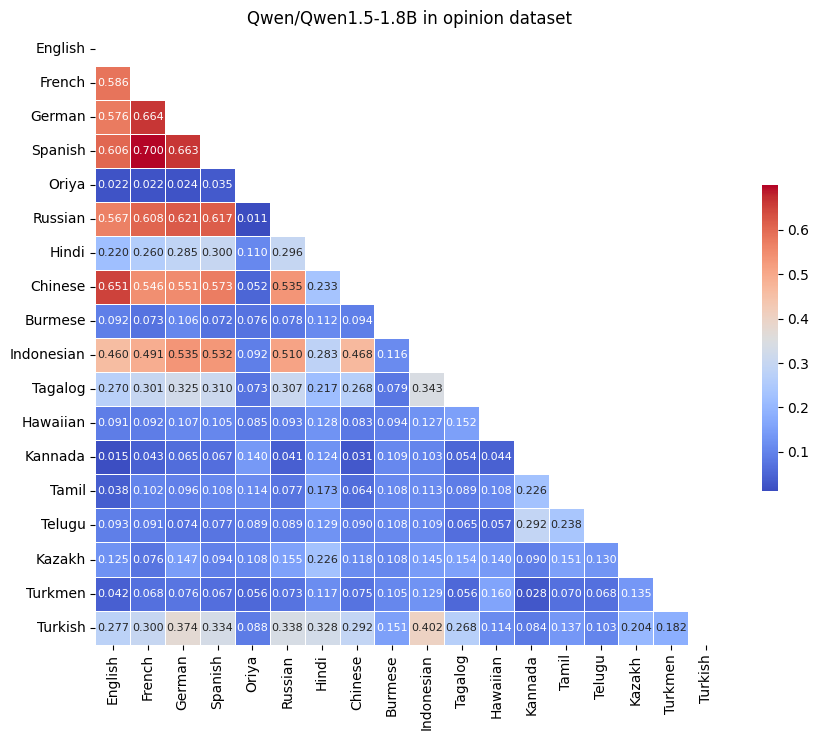

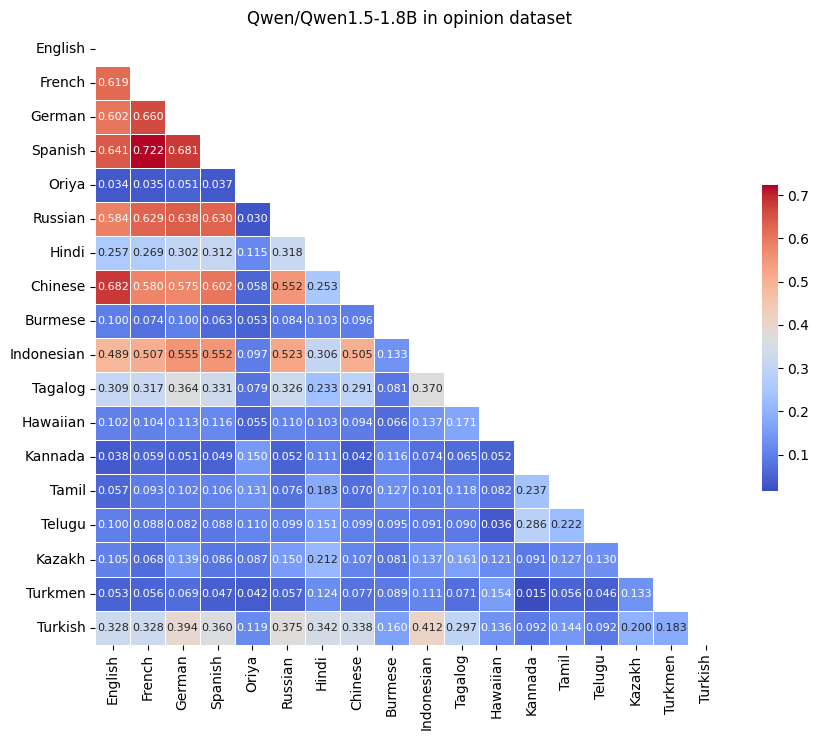

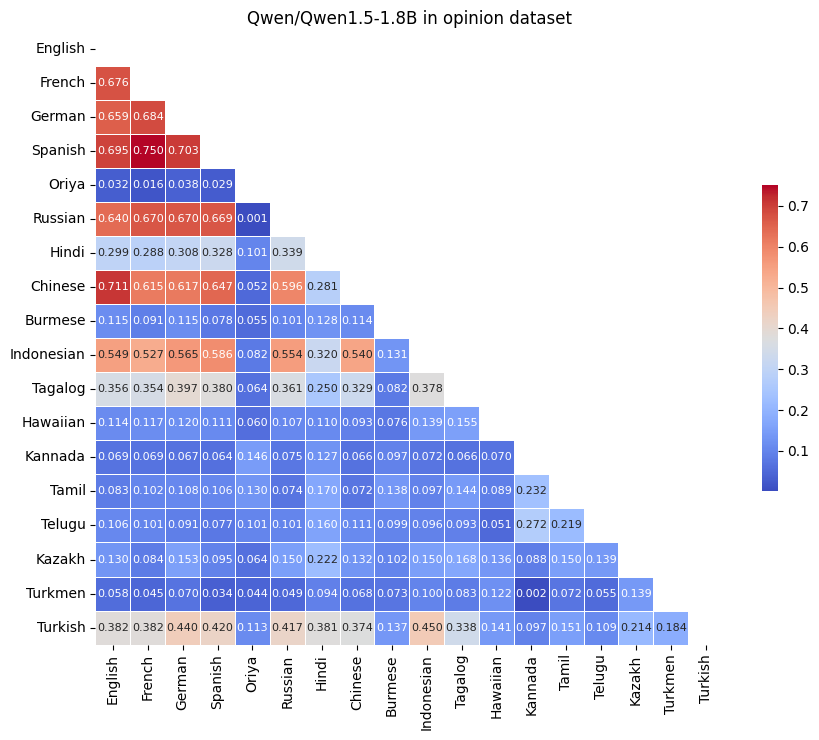

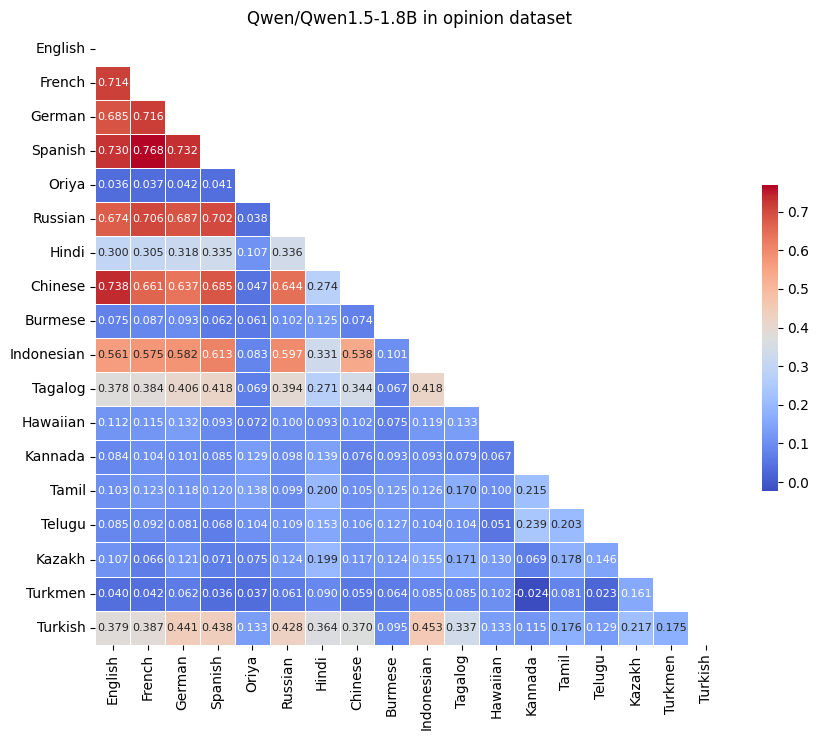

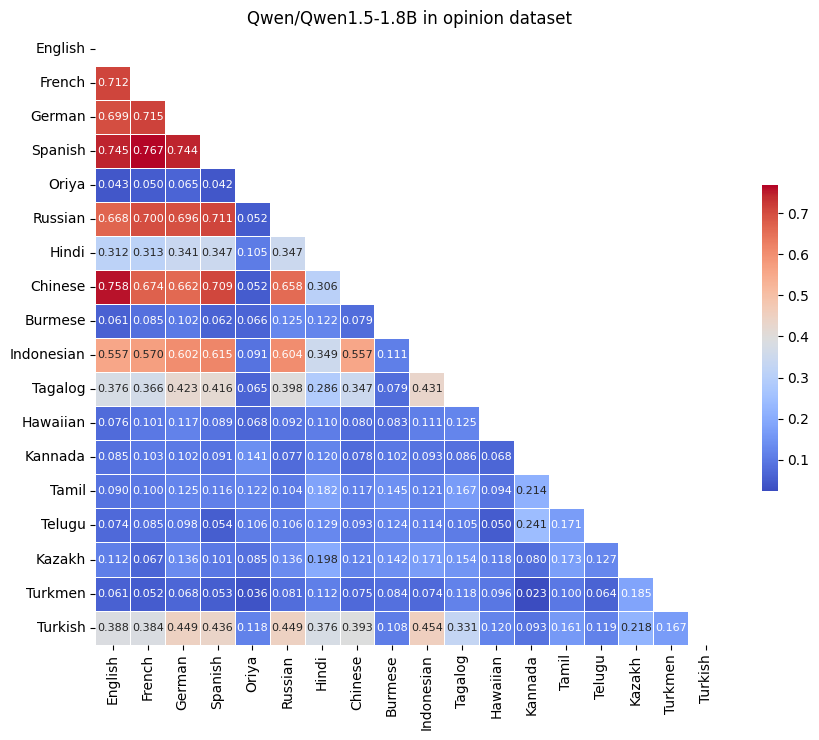

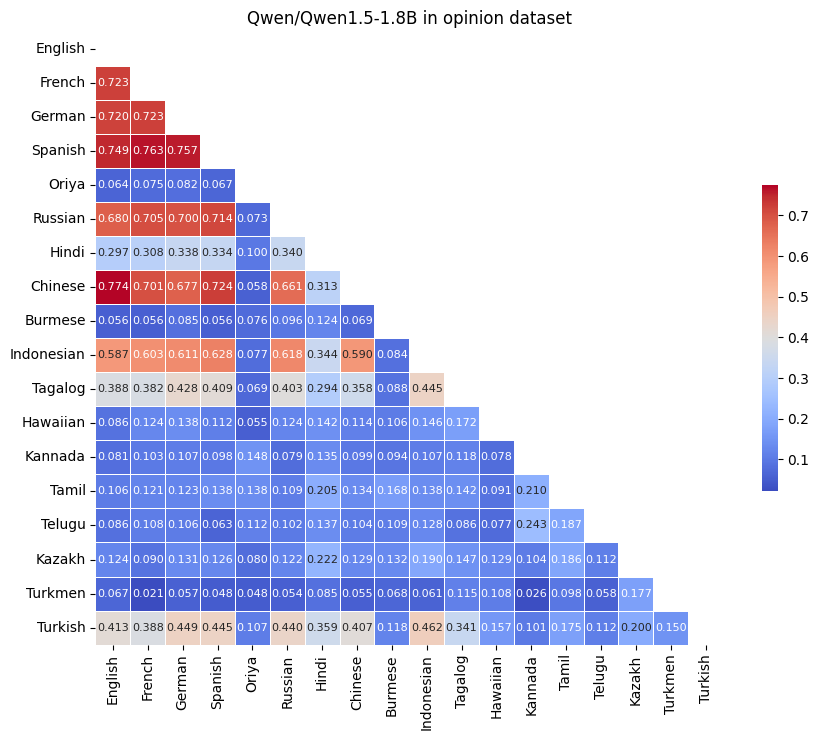

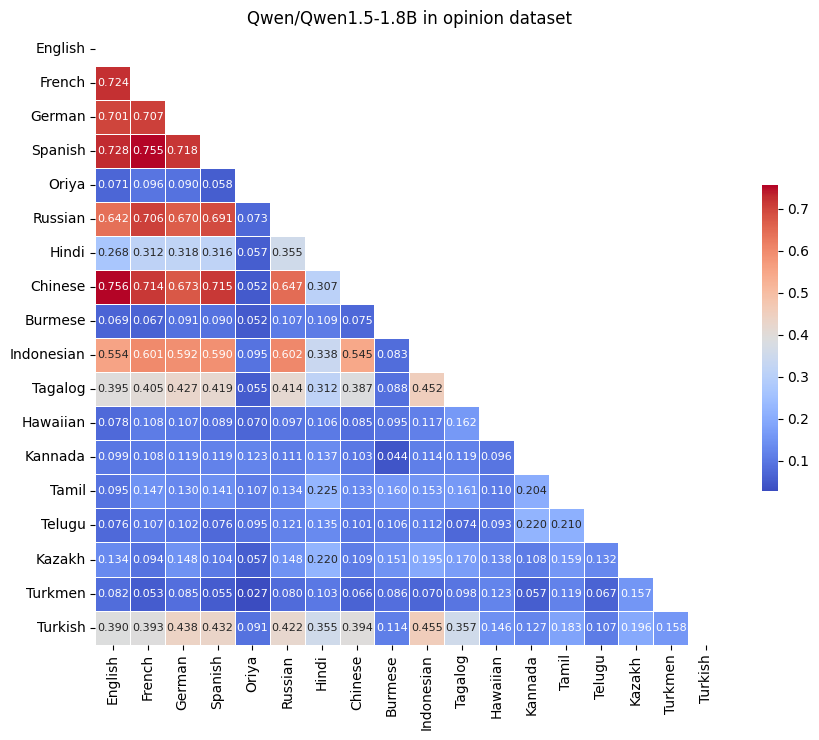

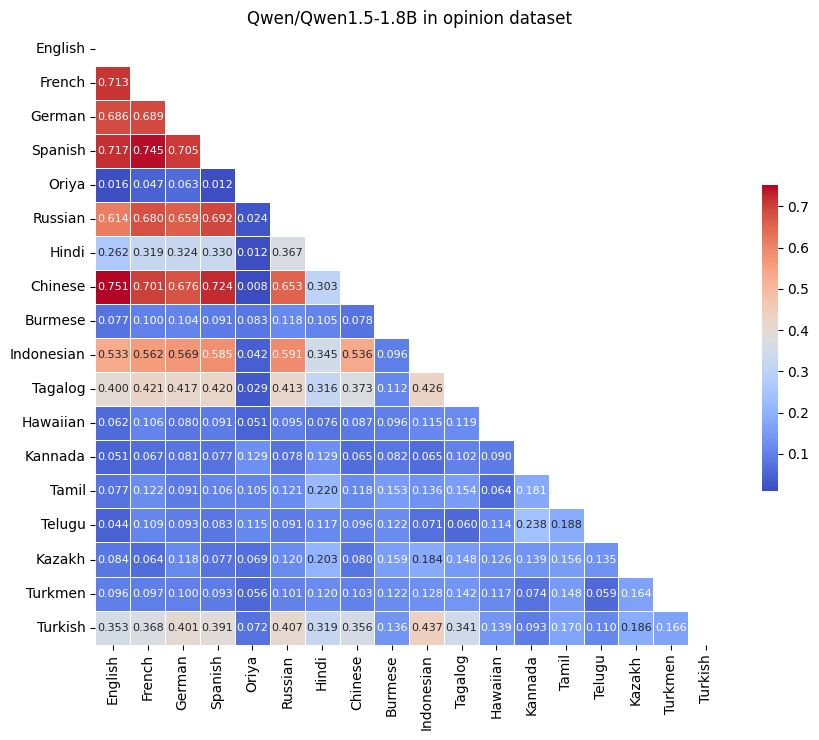

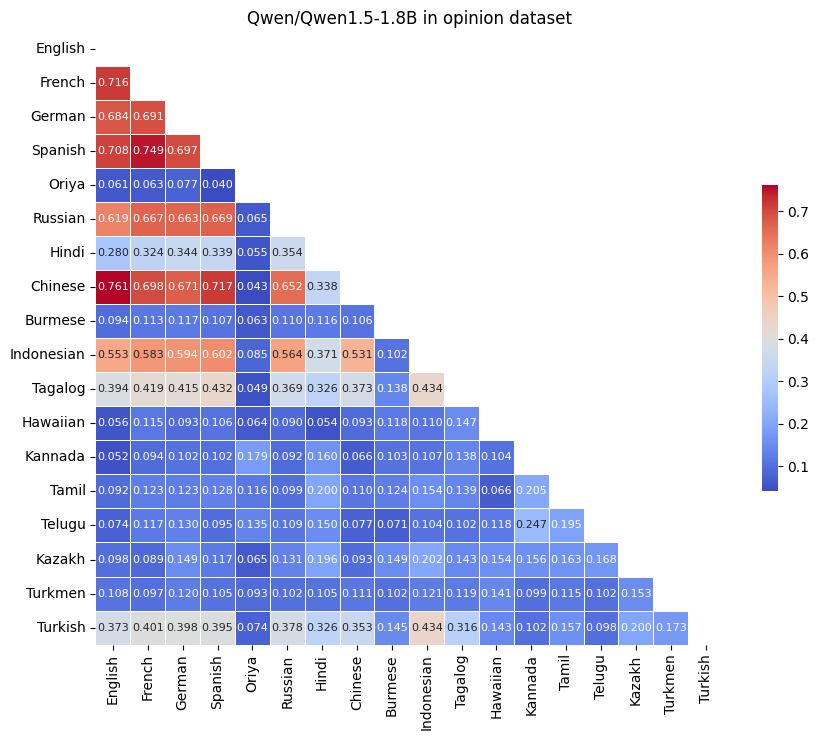

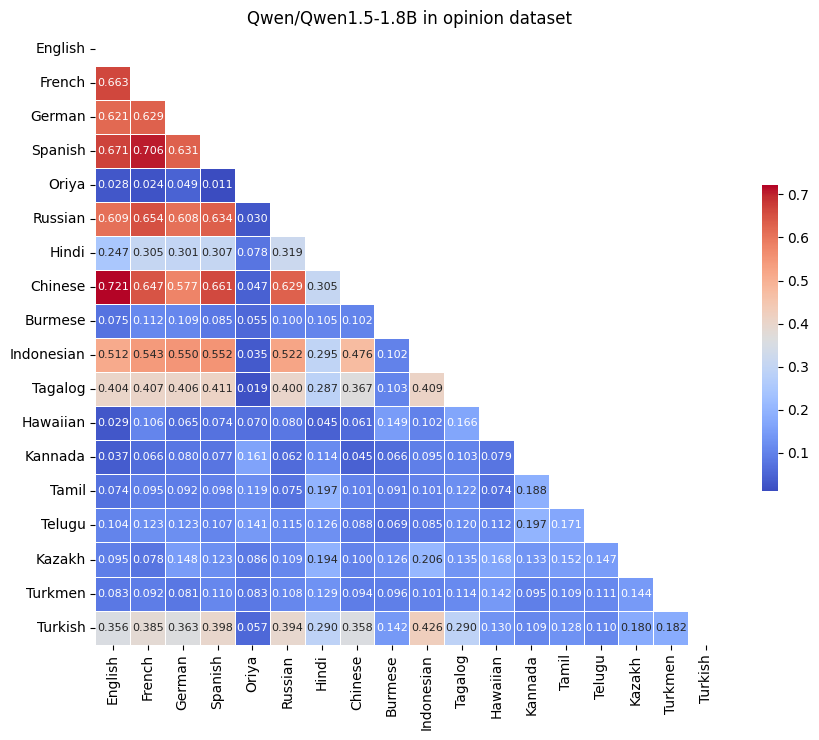

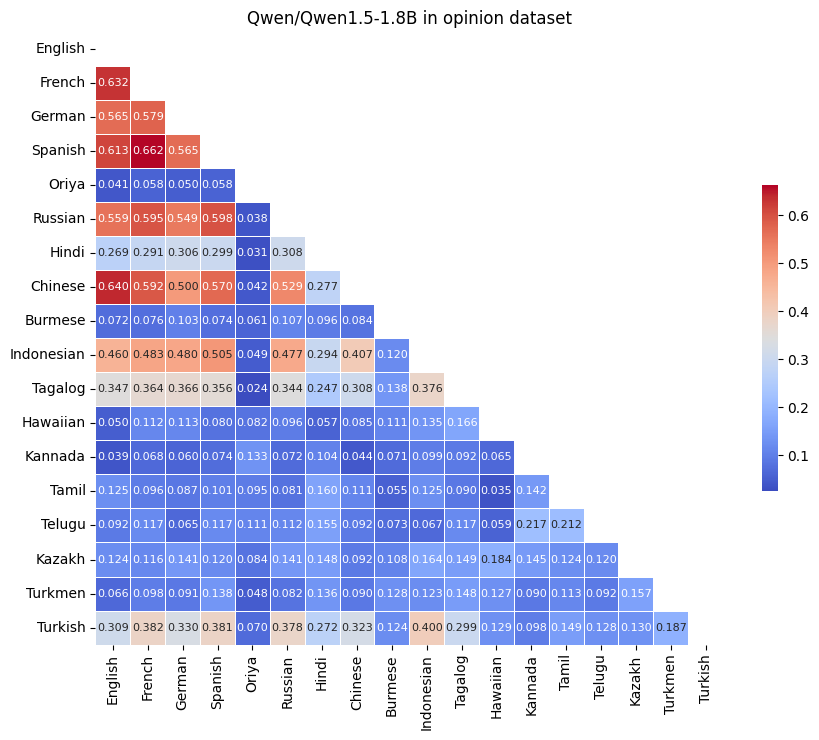

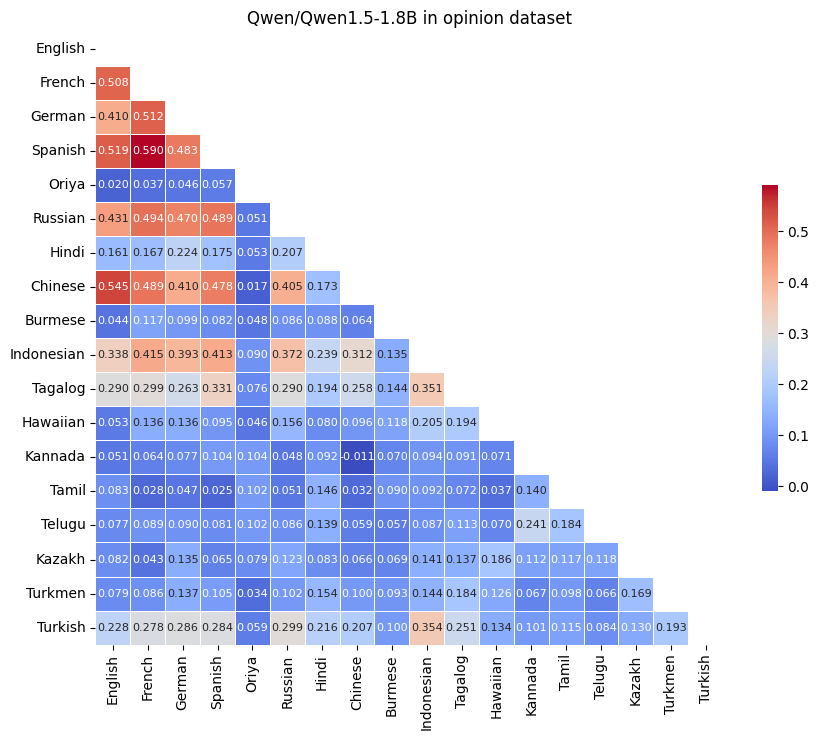

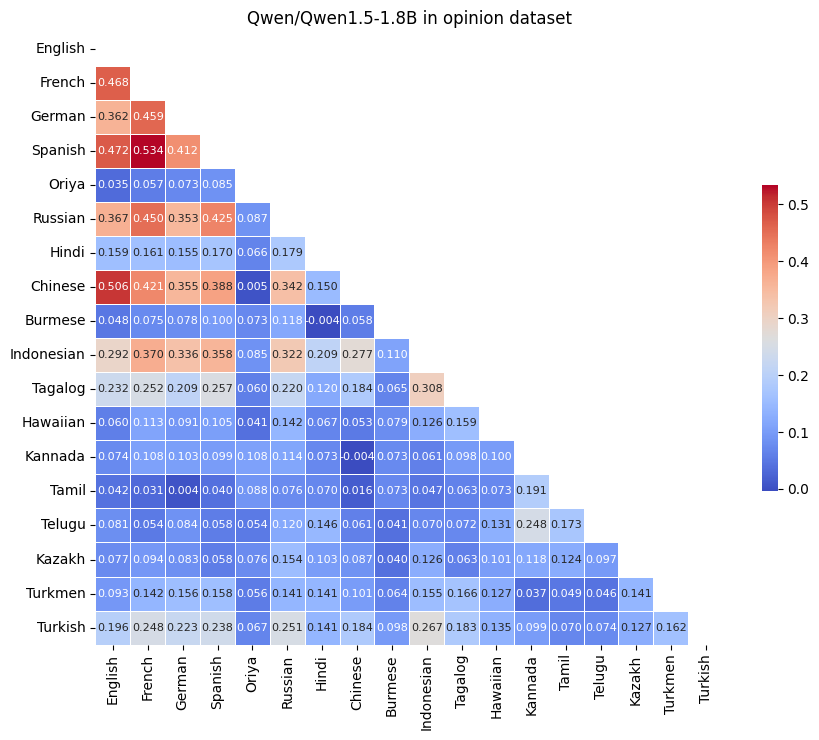

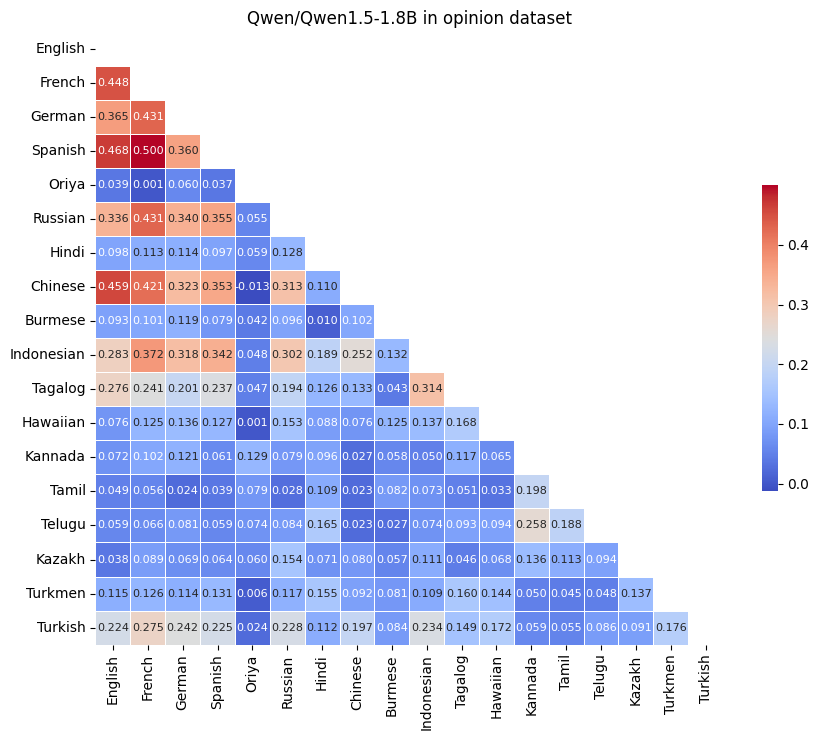

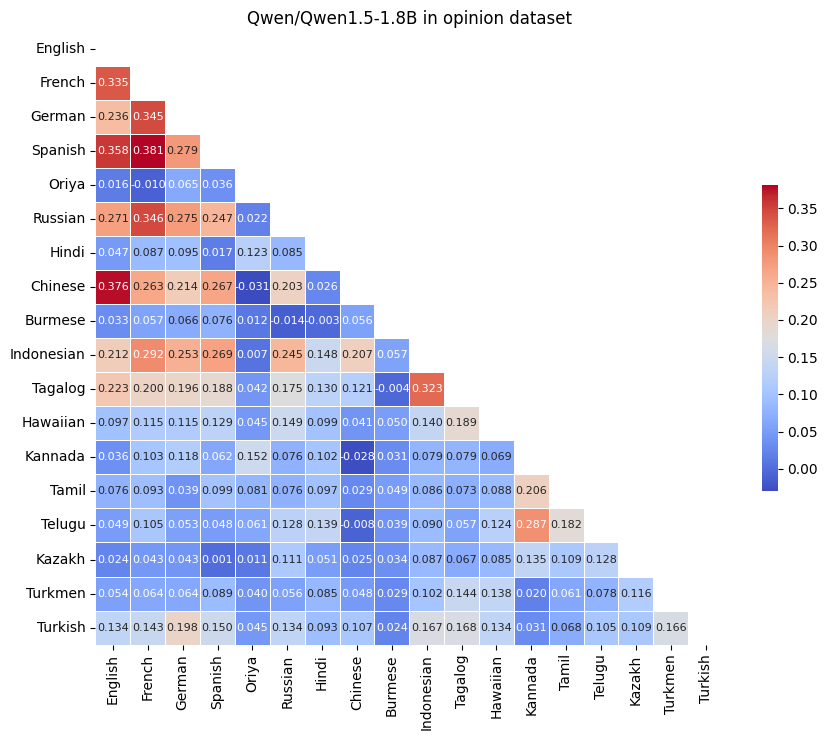

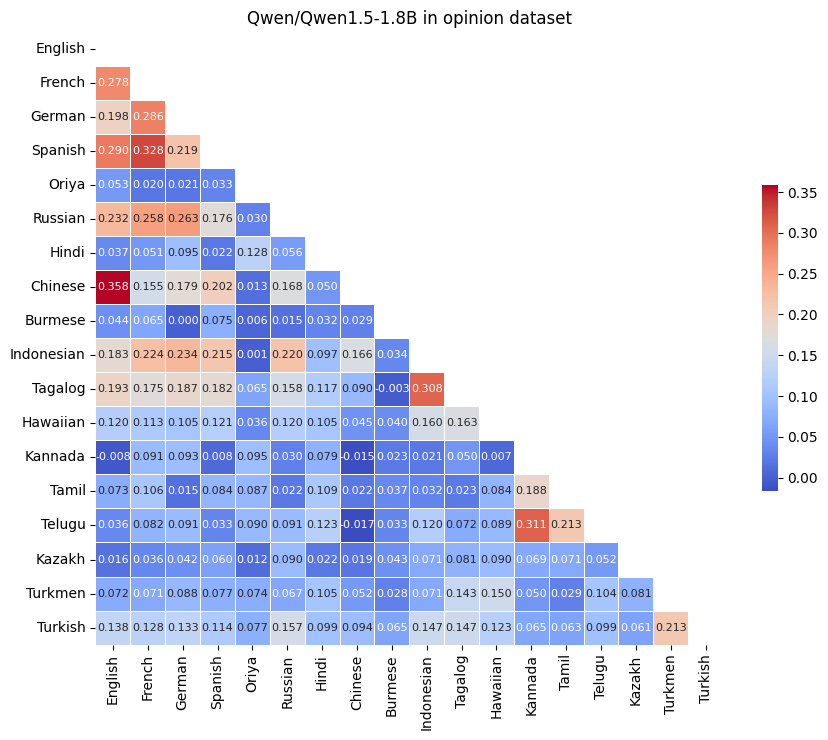

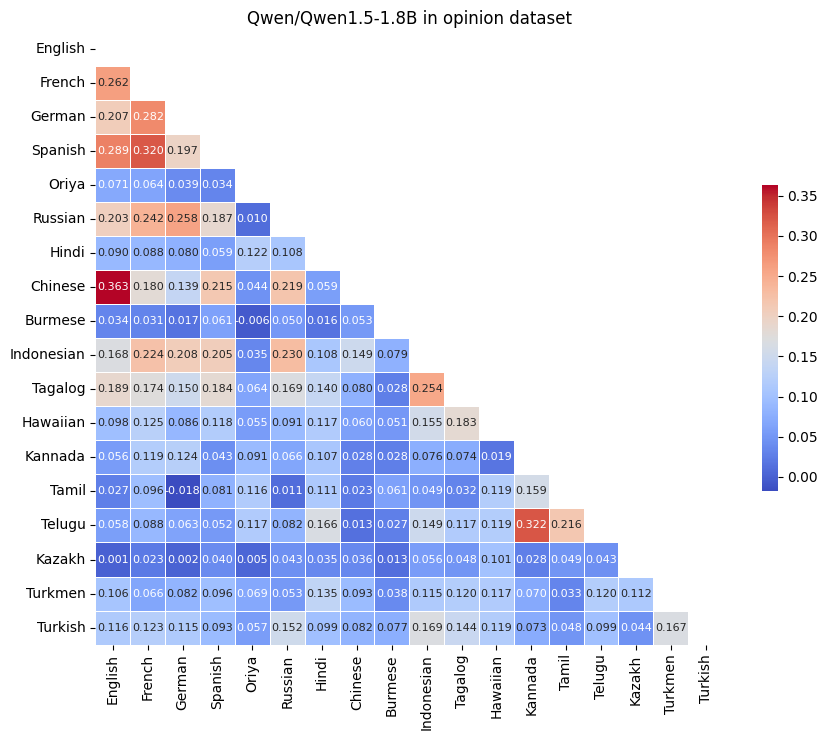

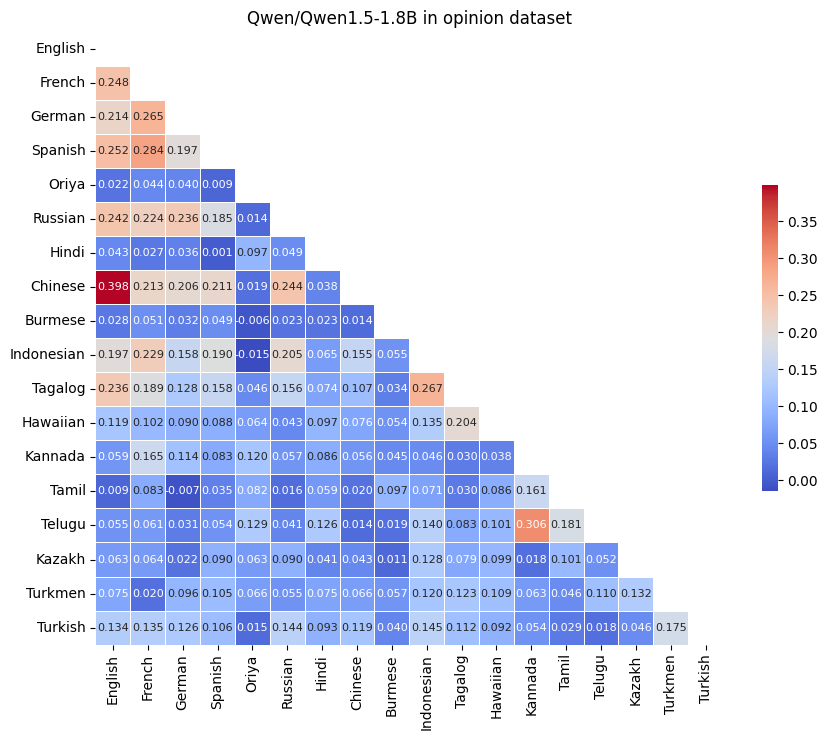

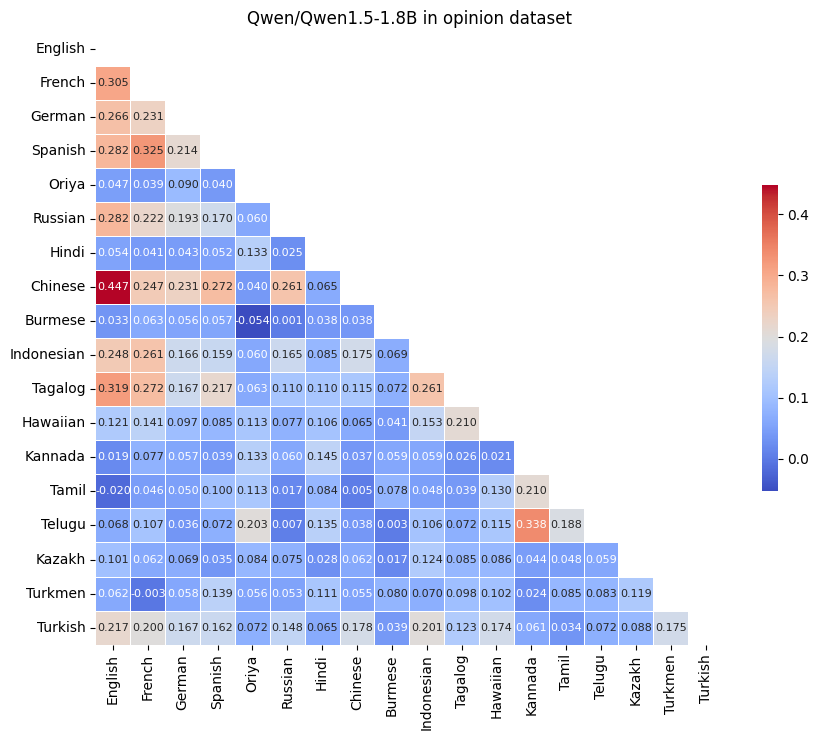

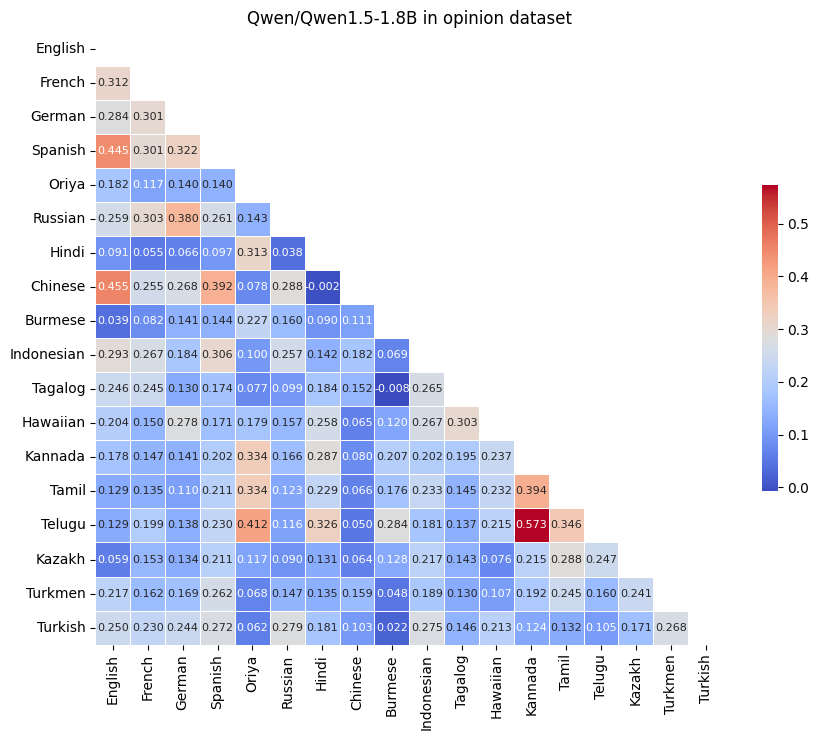

In [14]:
def print_weights_layers(dataset, model):
    # Main code
    
    model_name_refresh = {"google/gemma-7b": "gemma-7b", "google/gemma-2b": "gemma-2b",
                              "meta-llama/Llama-2-7b-chat-hf": "Llama-7b",
                              "meta-llama/Llama-2-13b-chat-hf": "Llama-13b",
                              "meta-llama/Llama-2-70b-chat-hf": "Llama-70b", "Qwen/Qwen1.5-0.5B": "Qwen-0.5B",
                              "Qwen/Qwen1.5-1.8B": "Qwen-1.8B", "Qwen/Qwen1.5-4B": "Qwen-4B",
                              "Qwen/Qwen1.5-7B": "Qwen-7B", "Qwen/Qwen1.5-14B": "Qwen-14B",
                              "Qwen/Qwen1.5-72B": "Qwen-72B"}
    model_name = model_name_refresh[model]
    
    model_2_layer = {"google/gemma-7b": 28, "google/gemma-2b": 18, "meta-llama/Llama-2-7b-chat-hf": 32,
                 "meta-llama/Llama-2-13b-chat-hf": 40, "meta-llama/Llama-2-70b-chat-hf": 80,
                 "Qwen/Qwen1.5-0.5B": 24, "Qwen/Qwen1.5-1.8B": 24, "Qwen/Qwen1.5-4B": 40, 
                 "Qwen/Qwen1.5-7B": 32, "Qwen/Qwen1.5-14B": 40, "Qwen/Qwen1.5-72B": 80}
    
    for i in reversed(range(model_2_layer[model])):
        if i in range(20):
#             if i == 12:
#                 continue
            filename = 'results/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '.txt'
            weights_dict = read_weights(filename)

            # Calculate similarities for each language pair
            languages = list(weights_dict.keys())
            similarity_data = {lang: [] for lang in languages}

            for ref_language in languages:
                ref_weights = weights_dict[ref_language]
                for language in languages:
                    similarity = cosine_similarity(ref_weights, weights_dict[language])
                    similarity_data[ref_language].append(similarity)

            # Convert to DataFrame
            df = pd.DataFrame(similarity_data, index=languages, columns=languages)

            # Create mask for the upper triangle
            mask = np.triu(np.ones_like(df, dtype=bool))

            # Set up the matplotlib figure
            plt.figure(figsize=(9, 7.5))  # Increase figure size

            # Draw the heatmap
#             sns.heatmap(
#                 df,
#                 mask=mask,
#                 cmap='coolwarm',
#                 annot=True,
#                 fmt=".4f",  # Display four decimal places
#                 annot_kws={"size": 8},  # Adjust font size
#                 linewidths=.5,
#                 cbar_kws={"shrink": .5}
#             )
            sns.heatmap(
                df,
                mask=mask,
                cmap='coolwarm',
                annot=True,
                fmt=".3f",  # Display three decimal places
                annot_kws={"size": 8},  # Adjust font size
                linewidths=.5,
                cbar_kws={"shrink": .5}
            )

            # Title and labels
            plt.title(f'{model} in {dataset} dataset')

            # Adjust layout
            plt.tight_layout()

            # Save and show plot
#             save_path = f'results/weights/{model_name}_{dataset}_'+str(i)+'.png'
#             plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.show()
#             break
        
        
print_weights_layers('opinion', "Qwen/Qwen1.5-1.8B")

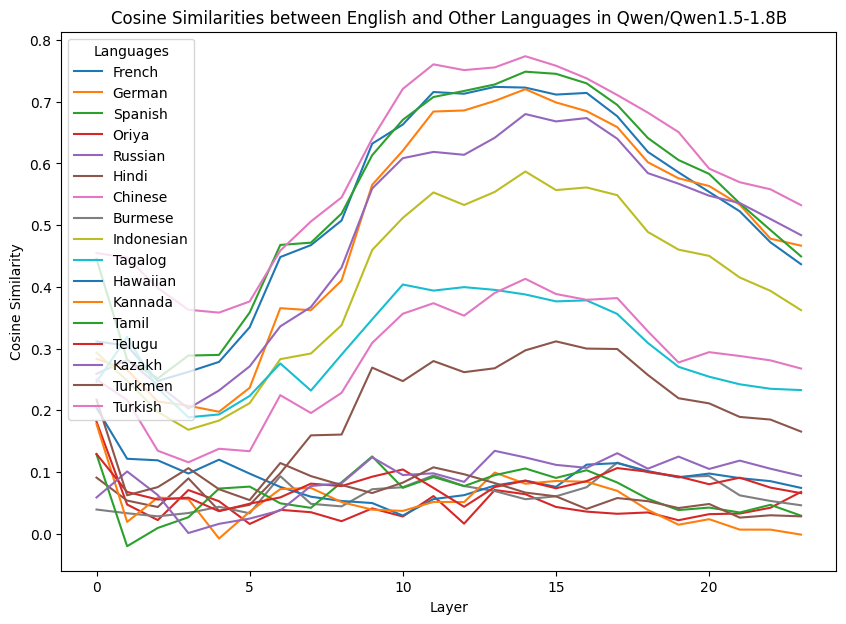

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import seaborn as sns

def print_weights_layers(dataset, model):
    # 更新模型名称映射
    model_name_refresh = {"google/gemma-7b": "gemma-7b", "google/gemma-2b": "gemma-2b",
                          "meta-llama/Llama-2-7b-chat-hf": "Llama-7b",
                          "meta-llama/Llama-2-13b-chat-hf": "Llama-13b",
                          "meta-llama/Llama-2-70b-chat-hf": "Llama-70b", 
                          "Qwen/Qwen1.5-0.5B": "Qwen-0.5B",
                          "Qwen/Qwen1.5-1.8B": "Qwen-1.8B", "Qwen/Qwen1.5-4B": "Qwen-4B",
                          "Qwen/Qwen1.5-7B": "Qwen-7B", "Qwen/Qwen1.5-14B": "Qwen-14B",
                          "Qwen/Qwen1.5-72B": "Qwen-72B"}
    model_name = model_name_refresh[model]
    
    # 模型对应层数
    model_2_layer = {"google/gemma-7b": 28, "google/gemma-2b": 18, "meta-llama/Llama-2-7b-chat-hf": 32,
                     "meta-llama/Llama-2-13b-chat-hf": 40, "meta-llama/Llama-2-70b-chat-hf": 80,
                     "Qwen/Qwen1.5-0.5B": 24, "Qwen/Qwen1.5-1.8B": 24, "Qwen/Qwen1.5-4B": 40, 
                     "Qwen/Qwen1.5-7B": 32, "Qwen/Qwen1.5-14B": 40, "Qwen/Qwen1.5-72B": 80}
    
    # 存储不同语言在各个层的相似度
    language_similarities = {}

    # 迭代层
    for i in reversed(range(model_2_layer[model])):
        filename = 'results/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '.txt'
        weights_dict = read_weights(filename)

        # 只计算 English 与其他语言的相似度
        languages = list(weights_dict.keys())
        if "English" not in languages:
            continue  # 如果没有 English 这门语言，跳过此层

        ref_weights = weights_dict["English"]

        for language in languages:
            if language == "English":
                continue  # 跳过 English 自身的比较
            
            # 计算 English 与其他语言的相似度
            similarity = cosine_similarity(ref_weights, weights_dict[language])
            
            # 将相似度存储到字典中，按语言记录每层的相似度
            if language not in language_similarities:
                language_similarities[language] = []
            language_similarities[language].append(similarity)
    
    # 绘制相似度随层变化的曲线图
    plt.figure(figsize=(10, 7))

    # X轴是模型层的索引
    layers = list(reversed(range(model_2_layer[model])))

    # 绘制每种语言的曲线
    for language, similarities in language_similarities.items():
        plt.plot(layers[:len(similarities)], similarities, label=language)

    # 设置图表标题和标签
    plt.title(f'Cosine Similarities between English and Other Languages in {model}')
    plt.xlabel('Layer')
    plt.ylabel('Cosine Similarity')
    plt.legend(title='Languages')

    # 展示图表
    plt.show()

# 调用函数计算和绘图
print_weights_layers('opinion', "Qwen/Qwen1.5-1.8B")

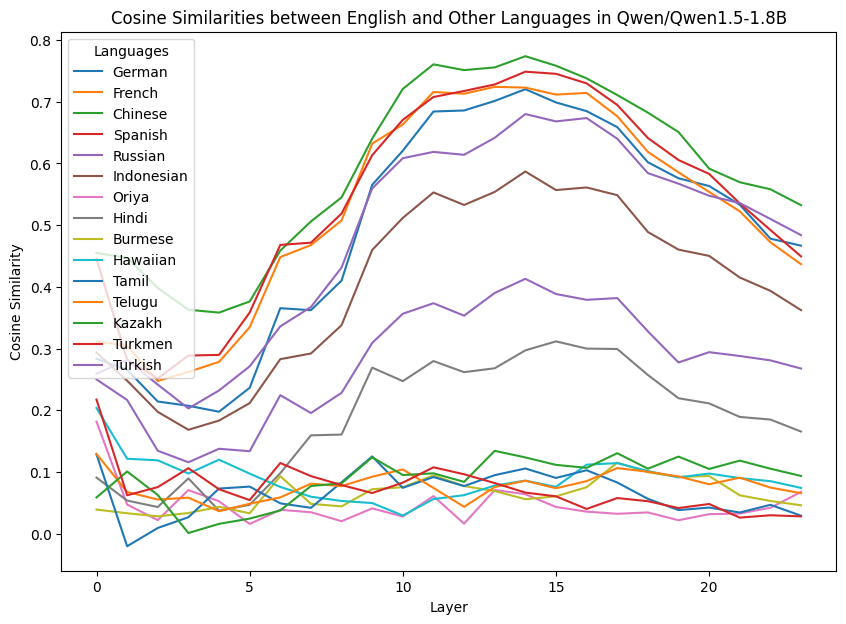

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import seaborn as sns

def print_weights_layers(dataset, model):
    # 更新模型名称映射
    model_name_refresh = {"google/gemma-7b": "gemma-7b", "google/gemma-2b": "gemma-2b",
                          "meta-llama/Llama-2-7b-chat-hf": "Llama-7b",
                          "meta-llama/Llama-2-13b-chat-hf": "Llama-13b",
                          "meta-llama/Llama-2-70b-chat-hf": "Llama-70b", 
                          "Qwen/Qwen1.5-0.5B": "Qwen-0.5B",
                          "Qwen/Qwen1.5-1.8B": "Qwen-1.8B", "Qwen/Qwen1.5-4B": "Qwen-4B",
                          "Qwen/Qwen1.5-7B": "Qwen-7B", "Qwen/Qwen1.5-14B": "Qwen-14B",
                          "Qwen/Qwen1.5-72B": "Qwen-72B"}
    model_name = model_name_refresh[model]
    
    # 模型对应层数
    model_2_layer = {"google/gemma-7b": 28, "google/gemma-2b": 18, "meta-llama/Llama-2-7b-chat-hf": 32,
                     "meta-llama/Llama-2-13b-chat-hf": 40, "meta-llama/Llama-2-70b-chat-hf": 80,
                     "Qwen/Qwen1.5-0.5B": 24, "Qwen/Qwen1.5-1.8B": 24, "Qwen/Qwen1.5-4B": 40, 
                     "Qwen/Qwen1.5-7B": 32, "Qwen/Qwen1.5-14B": 40, "Qwen/Qwen1.5-72B": 80}
    
    # 使用的语言列表
    language_abbreviations = [
        'English', 'German', 'French', 'Chinese', 'Spanish', 
        'Russian', 'Indonesian', 'Oriya', 'Hindi', 'Burmese', 
        'Hawaiian', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen', 'Turkish'
    ]
    
    # 存储不同语言在各个层的相似度
    language_similarities = {lang: [] for lang in language_abbreviations}

    # 迭代层
    for i in reversed(range(model_2_layer[model])):
        filename = 'results/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '.txt'
        weights_dict = read_weights(filename)

        # 只计算 English 与其他语言的相似度
        languages = list(weights_dict.keys())
        if "English" not in languages:
            continue  # 如果没有 English 这门语言，跳过此层

        ref_weights = weights_dict["English"]

        for language in language_abbreviations:
            if language not in weights_dict:
                continue  # 如果权重文件中没有该语言，跳过
            
            if language == "English":
                continue  # 跳过 English 自身的比较
            
            # 计算 English 与其他语言的相似度
            similarity = cosine_similarity(ref_weights, weights_dict[language])
            
            # 将相似度存储到字典中，按语言记录每层的相似度
            language_similarities[language].append(similarity)
    
    # 绘制相似度随层变化的曲线图
    plt.figure(figsize=(10, 7))

    # X轴是模型层的索引
    layers = list(reversed(range(model_2_layer[model])))

    # 绘制每种语言的曲线，按照给定的顺序
    for language in language_abbreviations:
        if len(language_similarities[language]) > 0:
            plt.plot(layers[:len(language_similarities[language])], language_similarities[language], label=language)

    # 设置图表标题和标签
    plt.title(f'Cosine Similarities between English and Other Languages in {model}')
    plt.xlabel('Layer')
    plt.ylabel('Cosine Similarity')

    # 按指定顺序生成图例
    handles, labels = plt.gca().get_legend_handles_labels()
    sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: language_abbreviations.index(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_handles_labels)
    plt.legend(sorted_handles, sorted_labels, title='Languages')

    # 展示图表
    plt.show()

# 调用函数计算和绘图
print_weights_layers('opinion', "Qwen/Qwen1.5-1.8B")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


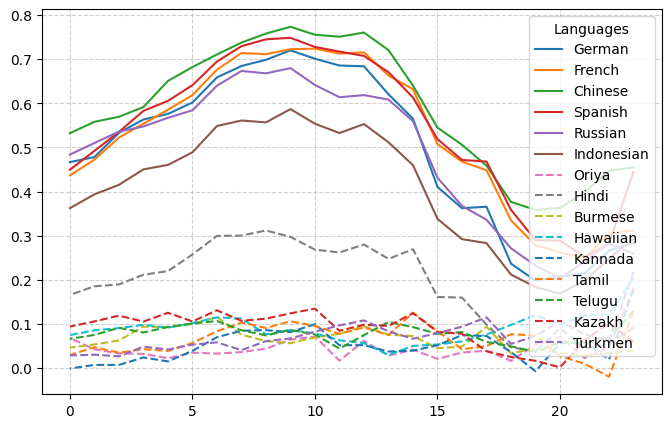

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import seaborn as sns

def print_weights_layers(dataset, model):
    # 更新模型名称映射
    model_name_refresh = {"google/gemma-7b": "gemma-7b", "google/gemma-2b": "gemma-2b",
                          "meta-llama/Llama-2-7b-chat-hf": "Llama-7b",
                          "meta-llama/Llama-2-13b-chat-hf": "Llama-13b",
                          "meta-llama/Llama-2-70b-chat-hf": "Llama-70b", 
                          "Qwen/Qwen1.5-0.5B": "Qwen-0.5B",
                          "Qwen/Qwen1.5-1.8B": "Qwen-1.8B", "Qwen/Qwen1.5-4B": "Qwen-4B",
                          "Qwen/Qwen1.5-7B": "Qwen-7B", "Qwen/Qwen1.5-14B": "Qwen-14B",
                          "Qwen/Qwen1.5-72B": "Qwen-72B"}
    model_name = model_name_refresh[model]
    
    # 模型对应层数
    model_2_layer = {"google/gemma-7b": 28, "google/gemma-2b": 18, "meta-llama/Llama-2-7b-chat-hf": 32,
                     "meta-llama/Llama-2-13b-chat-hf": 40, "meta-llama/Llama-2-70b-chat-hf": 80,
                     "Qwen/Qwen1.5-0.5B": 24, "Qwen/Qwen1.5-1.8B": 24, "Qwen/Qwen1.5-4B": 40, 
                     "Qwen/Qwen1.5-7B": 32, "Qwen/Qwen1.5-14B": 40, "Qwen/Qwen1.5-72B": 80}
    
    # 使用的语言列表
    language_abbreviations = [
        'English', 'German', 'French', 'Chinese', 'Spanish', 
        'Russian', 'Indonesian', 'Oriya', 'Hindi', 'Burmese', 
        'Hawaiian', 'Kannada', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen'
    ]
    
    # 存储不同语言在各个层的相似度
    language_similarities = {lang: [] for lang in language_abbreviations}

    # 迭代层
    for i in range(model_2_layer[model]):
        print(i)
        filename = 'results/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '.txt'
        weights_dict = read_weights(filename)

        # 只计算 English 与其他语言的相似度
        languages = list(weights_dict.keys())
        if "English" not in languages:
            continue  # 如果没有 English 这门语言，跳过此层

        ref_weights = weights_dict["English"]

        for language in language_abbreviations:
            if language not in weights_dict:
                continue  # 如果权重文件中没有该语言，跳过
            
            if language == "English":
                continue  # 跳过 English 自身的比较
            
            # 计算 English 与其他语言的相似度
            similarity = cosine_similarity(ref_weights, weights_dict[language])
            
            # 将相似度存储到字典中，按语言记录每层的相似度
            language_similarities[language].append(similarity)
    
    # 实线的语言
    solid_line_languages = ['English', 'German', 'French', 'Chinese', 'Spanish', 'Russian', 'Indonesian']

    # 绘制相似度随层变化的曲线图
    plt.figure(figsize=(8, 5))

    # X轴是模型层的索引
    layers = list(reversed(range(model_2_layer[model])))

    # 绘制每种语言的曲线，按照给定的顺序
    for language in language_abbreviations:
        if len(language_similarities[language]) > 0:
            if language in solid_line_languages:
                plt.plot(layers[:len(language_similarities[language])], language_similarities[language], label=language, linestyle='-')  # 实线
            else:
                plt.plot(layers[:len(language_similarities[language])], language_similarities[language], label=language, linestyle='--')  # 虚线

    # 设置图表标题和标签
#     plt.title(f'Cosine Similarities between English and Other Languages in {model}')
#     plt.xlabel('Layer')
#     plt.ylabel('Cosine Similarity')

    # 绘制网格并设置虚线背景
    plt.grid(True, linestyle='--', alpha=0.6)

    # 按指定顺序生成图例
    handles, labels = plt.gca().get_legend_handles_labels()
    sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: language_abbreviations.index(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_handles_labels)
    plt.legend(sorted_handles, sorted_labels, title='Languages')
    pdf_filename = f'results/figure/{dataset}/{model_name}_{dataset}_vector_v1.pdf'.replace(' ', '_')
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

    # 展示图表
    plt.show()

# 调用函数计算和绘图
print_weights_layers('opinion', "Qwen/Qwen1.5-1.8B")

opinion Qwen/Qwen1.5-1.8B
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


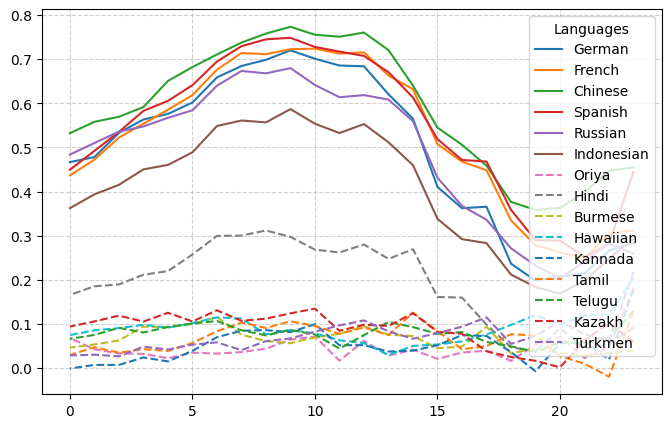

opinion google/gemma-2b
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


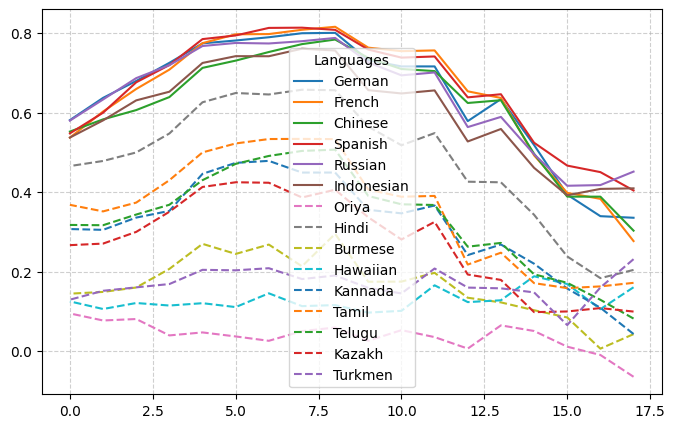

cities Qwen/Qwen1.5-1.8B
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


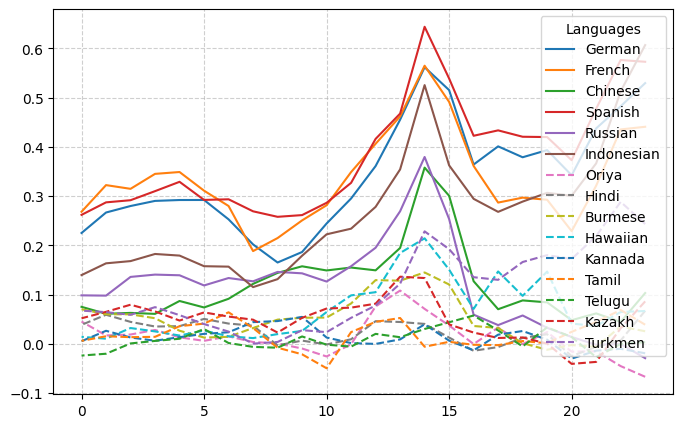

cities google/gemma-2b
0
1
2
3
4
5
6
7
8
9
10
11
12


ValueError: shapes (2044,) and (2042,) not aligned: 2044 (dim 0) != 2042 (dim 0)

In [13]:
dataset = ['opinion', 'cities']
model = ["Qwen/Qwen1.5-1.8B", "google/gemma-2b"]
for d in dataset:
    for m in model:
        print(d, m)
        print_weights_layers(d, m)

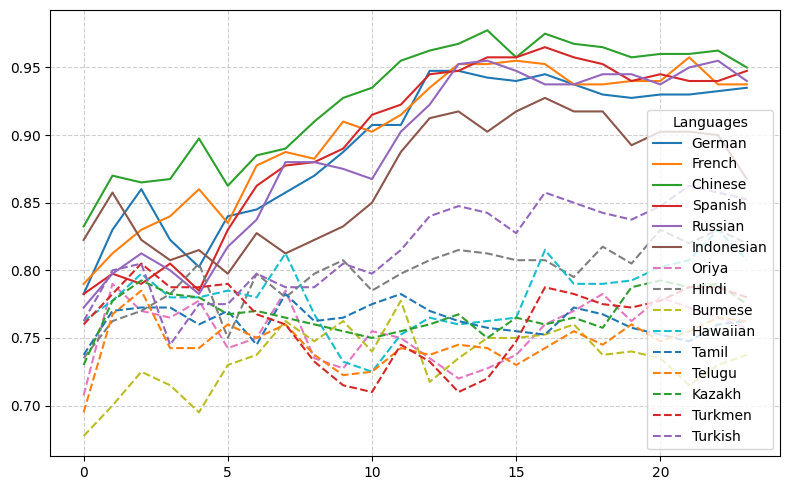

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
file_path = 'language_similarity.csv'
df = pd.read_csv(file_path)

# Convert the 'Average Similarity' to numeric (in case it's not)
df['Average Similarity'] = pd.to_numeric(df['Average Similarity'], errors='coerce')

# Language abbreviations
language_abbreviations = [
    'English', 'German', 'French', 'Chinese', 'Spanish', 
    'Russian', 'Indonesian', 'Oriya', 'Hindi', 'Burmese', 
    'Hawaiian', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen', 'Turkish'
]

# Extract unique epochs (or layers in your context)
layers = df['Epoch'].unique()

# Languages that should have solid lines
solid_line_languages = ['English', 'German', 'French', 'Chinese', 'Spanish', 'Russian', 'Indonesian']

# Dictionary to store language similarities over different layers
language_similarities = {lang: [] for lang in language_abbreviations}

# Loop through each layer (epoch) to compute English similarity with others
for layer in layers:
    # Filter the data for the current layer
    layer_data = df[df['Epoch'] == layer]
    
    # Filter out English vs other languages
    english_data = layer_data[layer_data['Language 1'] == 'English']
    
    # Add similarities for each language
    for lang in language_abbreviations:
        if lang != 'English':
            similarity = english_data[english_data['Language 2'] == lang]['Average Similarity'].values
            if len(similarity) > 0:
                language_similarities[lang].append(similarity[0])
            else:
                language_similarities[lang].append(None)

# Remove "English" from the plotting process
language_abbreviations_without_english = language_abbreviations[1:]  # Remove "English" from the list

# Plotting without "English"
plt.figure(figsize=(8, 5))

# X-axis: layers
layer_indices = range(len(layers))

# Plot each language's similarity over layers
for language in language_abbreviations_without_english:
    if language in solid_line_languages:
        plt.plot(layer_indices, language_similarities[language], label=language, linestyle='-')  # Solid line
    else:
        plt.plot(layer_indices, language_similarities[language], label=language, linestyle='--')  # Dashed line

# Configure plot
# plt.title('Cosine Similarities between English and Other Languages across Layers')
# plt.xlabel('Layer')
# plt.ylabel('Cosine Similarity')

# Add grid with dashed background
plt.grid(True, linestyle='--', alpha=0.6)

# Ensure legend is in the order of language_abbreviations
handles, labels = plt.gca().get_legend_handles_labels()
sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: language_abbreviations_without_english.index(x[1]))
sorted_handles, sorted_labels = zip(*sorted_handles_labels)
plt.legend(sorted_handles, sorted_labels, title='Languages')

# Show the plot
plt.tight_layout()
pdf_filename = f'results/figure/opinion/Qwen-0.5B_opinion_question_v1.pdf'.replace(' ', '_')
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
plt.show()